CIFAR-10 Custom CNN Training with Checkpoint Resume (Colab T4)

Setup

In [1]:
import os
import torch
import random
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Project Path

In [3]:
BASE_DIR = "/content/drive/MyDrive/indigenous_ai_project"
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
DATA_DIR = os.path.join(BASE_DIR, "data")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Reproducibility

In [6]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Dataset (CIFAR 10)

In [7]:
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.CIFAR10(
root=DATA_DIR,
train=True,
download=True,
transform=transform
)
train_loader = DataLoader(
train_dataset,
batch_size=128,
shuffle=True,
num_workers=2,
pin_memory=True
)

100%|██████████| 170M/170M [00:07<00:00, 21.8MB/s]


Model Custom CNN

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


model = SimpleCNN().to(device)

Optimizer and Loss

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Checkpoint Handling

In [12]:
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

start_epoch = 0
global_step = 0


def save_checkpoint(epoch, step):
    torch.save({
        "epoch": epoch,
        "step": step,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "seed": SEED
    }, CHECKPOINT_PATH)


def load_checkpoint():
    global start_epoch, global_step

    if os.path.exists(CHECKPOINT_PATH):
        print("Opening checkpoint >")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])

        start_epoch = checkpoint["epoch"]
        global_step = checkpoint["step"]

        set_seed(checkpoint["seed"])

        print(f"Resumed from epoch {start_epoch}, step {global_step}")
    else:
        print("No checkpoint, starting fresh.")


load_checkpoint()

No checkpoint, starting fresh.


Training Loop

In [16]:
SAVE_EVERY_N_STEPS = 200
epoch = start_epoch  # resume from checkpoint
while True:  # infinite loop
    model.train()
    running_loss = 0.0
    print(f"\nStarting Epoch {epoch}")
    for batch_idx, (images, labels) in enumerate(train_loader):
        if epoch == start_epoch and batch_idx < (global_step % len(train_loader)):
            continue
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        global_step += 1
        if global_step % SAVE_EVERY_N_STEPS == 0:
            save_checkpoint(epoch, global_step)
            print(f"Checkpoint saved at step {global_step}")
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}] Batch [{batch_idx}] Loss: {loss.item():.4f}")
    save_checkpoint(epoch + 1, global_step)
    print(f"Epoch {epoch} completed. Avg Loss: {running_loss / len(train_loader):.4f}")
    epoch += 1
    start_epoch = epoch


Starting Epoch 0
Epoch [0] Batch [0] Loss: 0.8540
Checkpoint saved at step 800
Epoch [0] Batch [100] Loss: 0.9096
Epoch [0] Batch [200] Loss: 0.8806
Checkpoint saved at step 1000
Epoch [0] Batch [300] Loss: 0.7229
Epoch 0 completed. Avg Loss: 0.8558

Starting Epoch 1
Epoch [1] Batch [0] Loss: 0.6884
Checkpoint saved at step 1200
Epoch [1] Batch [100] Loss: 0.8613
Epoch [1] Batch [200] Loss: 0.6599
Checkpoint saved at step 1400
Epoch [1] Batch [300] Loss: 0.7821
Epoch 1 completed. Avg Loss: 0.7262

Starting Epoch 2
Epoch [2] Batch [0] Loss: 0.5174
Checkpoint saved at step 1600
Epoch [2] Batch [100] Loss: 0.6402
Epoch [2] Batch [200] Loss: 0.5453
Checkpoint saved at step 1800
Epoch [2] Batch [300] Loss: 0.5407
Epoch 2 completed. Avg Loss: 0.6255

Starting Epoch 3
Epoch [3] Batch [0] Loss: 0.4305
Checkpoint saved at step 2000
Epoch [3] Batch [100] Loss: 0.3810
Epoch [3] Batch [200] Loss: 0.3511
Checkpoint saved at step 2200
Epoch [3] Batch [300] Loss: 0.4756
Epoch 3 completed. Avg Loss: 

KeyboardInterrupt: 

Final Model Save

In [17]:
FINAL_MODEL_PATH = os.path.join(BASE_DIR, "final_model.pth")

torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "epoch": epoch,
    "step": global_step
}, FINAL_MODEL_PATH)

print("Final model saved")

Final model saved


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*MODEL TESTING-*-*-*-*-*-*-*-*-*-*-*-*-

Imports

In [18]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
from google.colab import files
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL DEFINITION (same as training)

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = SimpleCNN().to(device)

Load Model

In [20]:
MODEL_PATH = "/content/drive/MyDrive/indigenous_ai_project/final_model.pth"
checkpoint = torch.load(MODEL_PATH, map_location=device)
if "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("Model loaded successfully")

Model loaded successfully


CIFAR-10 CLASS LABELS

In [21]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

IMAGE TRANSFORM

In [22]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

UPLOAD IMAGE

Saving 3025003-poster-p-dog-2.webp to 3025003-poster-p-dog-2.webp


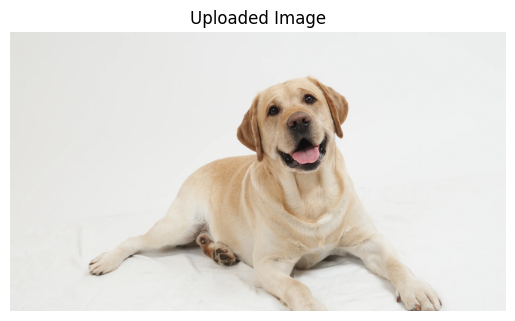

In [23]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

PREPROCESS + INFERENCE

In [24]:
input_tensor = transform(image).unsqueeze(0).to(device)
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

pred_class = classes[predicted.item()]
conf = confidence.item()

Output

In [25]:
print(f"Prediction: {pred_class}")
print(f"Confidence: {conf:.4f}")

Prediction: dog
Confidence: 1.0000
